In [1]:
import zipfile

# unzip train
with zipfile.ZipFile("train.zip", 'r') as zip_ref:
    zip_ref.extractall("train")

# unzip test
with zipfile.ZipFile("test.zip", 'r') as zip_ref:
    zip_ref.extractall("test")

KeyboardInterrupt: 

In [12]:
import os
from PIL import Image

def remove_corrupt_images(folder):
    for root, dirs, files in os.walk(folder):
        for file in files:
            path = os.path.join(root, file)
            try:
                img = Image.open(path)
                img.verify()
            except:
                print("Removing corrupted image:", path)
                os.remove(path)

remove_corrupt_images("/content/train")
remove_corrupt_images("/content/test")

Removing corrupted image: /content/train/train/dogs/dog.3547.jpg


In [13]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

In [14]:
#generator
from tensorflow import keras

train_ds = keras.utils.image_dataset_from_directory(
    '/content/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256),
    shuffle=True
)

validation_ds = keras.utils.image_dataset_from_directory(
    '/content/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 19999 files belonging to 1 classes.
Found 5000 files belonging to 1 classes.


In [15]:
#normalize
def process(image,label):
  image = tf.cast(image/255. ,tf.float32)
  return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)


In [16]:
from numpy import add
#CNN Model
model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [18]:
model.compile (optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [19]:
model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 112ms/step - accuracy: 0.9923 - loss: 0.0494 - val_accuracy: 1.0000 - val_loss: 2.7276e-22
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 89ms/step - accuracy: 1.0000 - loss: 1.6019e-33 - val_accuracy: 1.0000 - val_loss: 3.9304e-38
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 1.0000 - loss: 2.7114e-25 - val_accuracy: 1.0000 - val_loss: 3.1208e-38
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 95ms/step - accuracy: 1.0000 - loss: 9.0451e-34 - val_accuracy: 1.0000 - val_loss: 1.5906e-38
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 96ms/step - accuracy: 1.0000 - loss: 8.7035e-30 - val_accuracy: 1.0000 - val_loss: 3.2025e-38
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 89ms/step - accuracy: 1.0000 - loss: 5.0030e-28 - val_accuracy: 1.0000 - val_loss: 2.9487e-38
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 1.0000 - loss: 9.3193e-29 - val_accuracy: 1.0000 - val_loss: 4.1145e-38
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━

In [20]:
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 1.0000 - loss: 1.1231e-29 - val_accuracy: 1.0000 - val_loss: 3.1615e-38
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 95ms/step - accuracy: 1.0000 - loss: 8.5940e-25 - val_accuracy: 1.0000 - val_loss: 2.7488e-38
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 1.0000 - loss: 1.5023e-18 - val_accuracy: 1.0000 - val_loss: 2.2753e-38
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 1.0000 - loss: 1.3514e-23 - val_accuracy: 1.0000 - val_loss: 4.6100e-38
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 89ms/step - accuracy: 1.0000 - loss: 1.5932e-28 - val_accuracy: 1.0000 - val_loss: 2.1458e-38
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 95ms/step - accuracy: 1.0000 - loss: 1.3343e-21 - val_accuracy: 1.0000 - val_loss: 3.0314e-38
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 95ms/step - accuracy: 1.0000 - loss: 2.1636e-26 - val_accuracy: 1.0000 - val_loss: 2.9860e-38
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━

<function matplotlib.pyplot.show(close=None, block=None)>

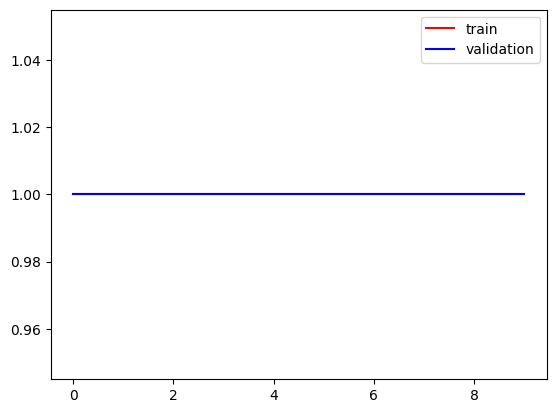

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

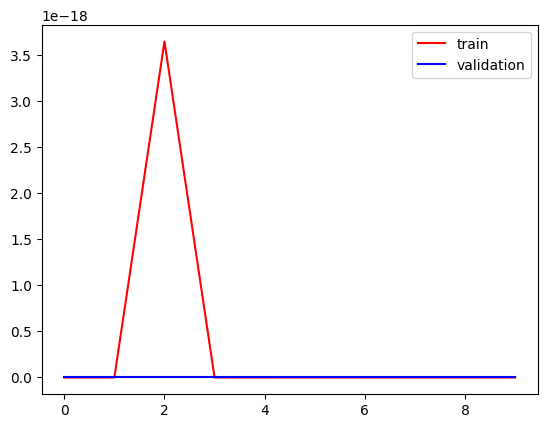

In [22]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show

In [23]:
import cv2


In [33]:
test_img= cv2.imread('/content/dog.webp')

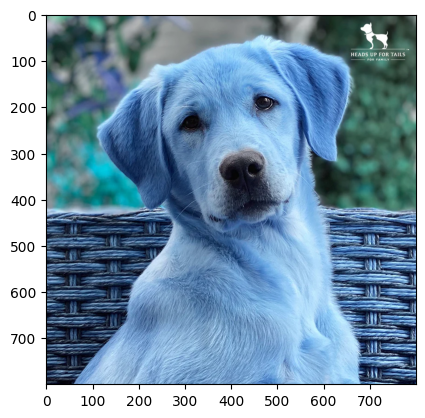

In [34]:
plt.imshow(test_img)

In [35]:
test_img.shape

(800, 800, 3)

In [36]:
test_input=cv2.resize(test_img,(256,256))

In [37]:
import numpy as np
test_input = test_input[np.newaxis, ...]

In [38]:
import tensorflow as tf

# Re-process test_img to ensure correct shape and normalization
test_input_processed = cv2.resize(test_img, (256, 256))
test_input_processed = test_input_processed[np.newaxis, ...]
test_input_processed = tf.cast(test_input_processed / 255., tf.float32)

# Now perform prediction
model.predict(test_input_processed)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[0.]], dtype=float32)